In [74]:
import pandas as pd
import numpy as np

df = pd.read_csv("customer_shopping_data.csv")  # using example data from Kaggle

print(df.shape)        
print(df.columns)  
print(df.head())  
print(df.dtypes)     
print(df.isnull().sum())
df.drop_duplicates()

(99457, 10)
Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  
0    Credit Card     5/8/2022          Kanyon  
1     Debit Card   12/12/2021  Forum Istanbul  
2           Cash    9/11/2021       Metrocity  
3    Credit Card   16/05/2021    Metropol AVM  
4           Cash   24/10/2021          Kanyon  
invoice_no         object
customer_id        object
gender             object
age                 int64
category

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park


In [3]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True)
print(df["invoice_date"].dtype)

datetime64[ns]


In [77]:
df["total_spend"] = df["quantity"] * df["price"]    #total spend per transaction
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_spend
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40


In [78]:
 print(df["total_spend"].mean())
 print(df["total_spend"].median())
 print(df["total_spend"].mode())

2528.7892682264696
600.17
0    1200.32
Name: total_spend, dtype: float64


In [79]:
print(df.groupby("category")["total_spend"].agg(["sum", "mean", "count"]).sort_values("sum", ascending = False)) # spending by category

print("------------------------------------------")

print(df.groupby("gender")["total_spend"].mean())     # spending by gender

print("------------------------------------------")

print(df.groupby("shopping_mall")["total_spend"].sum().sort_values(ascending=False))    # shopping mall with most spending

print("------------------------------------------")

print(df["payment_method"].value_counts())    # most common payment method

                          sum          mean  count
category                                          
Clothing         1.139968e+08   3305.500364  34487
Shoes            6.655345e+07   6632.793649  10034
Technology       5.786235e+07  11581.735388   4996
Cosmetics        6.792863e+06    449.947864  15097
Toys             3.980426e+06    394.609521  10087
Food & Beverage  8.495351e+05     57.494251  14776
Books            8.345529e+05    167.547260   4981
Souvenir         6.358247e+05    127.190368   4999
------------------------------------------
gender
Female    2525.253623
Male      2534.050237
Name: total_spend, dtype: float64
------------------------------------------
shopping_mall
Mall of Istanbul     50872481.68
Kanyon               50554231.10
Metrocity            37302787.33
Metropol AVM         25379913.19
Istinye Park         24618827.68
Zorlu Center         12901053.82
Cevahir AVM          12645138.20
Viaport Outlet       12521339.72
Emaar Square Mall    12406100.29
Forum Is

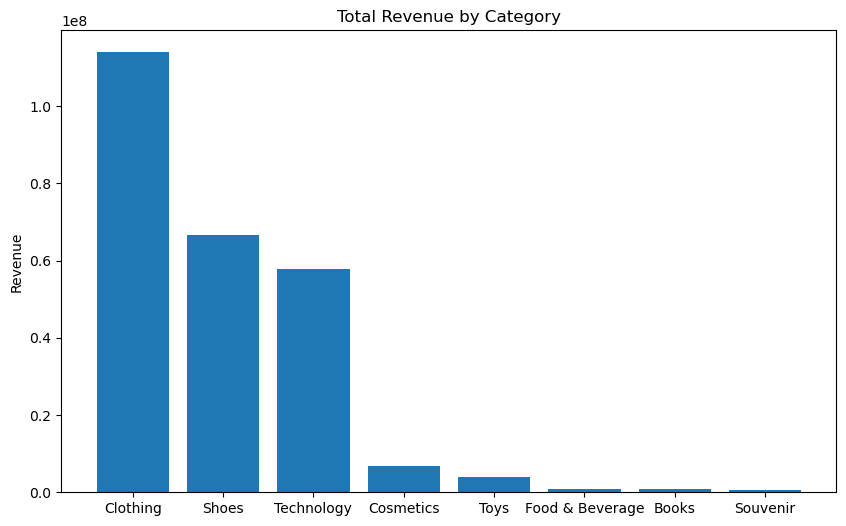

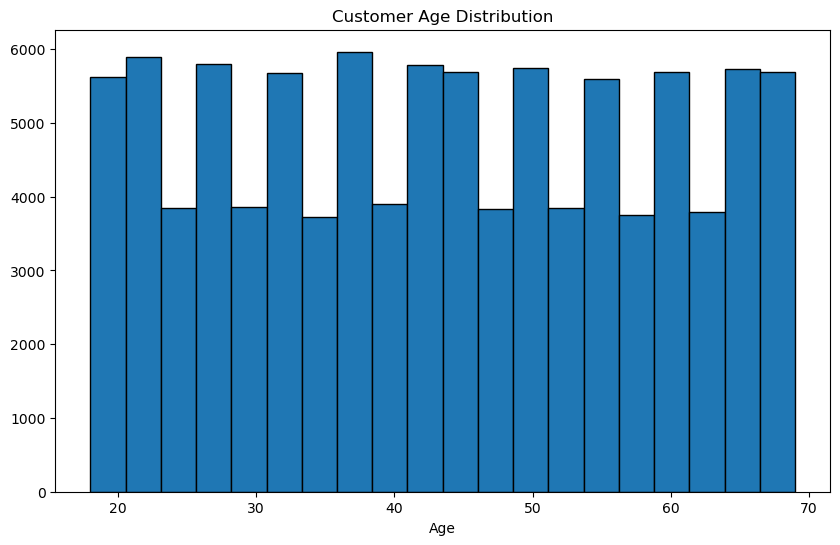

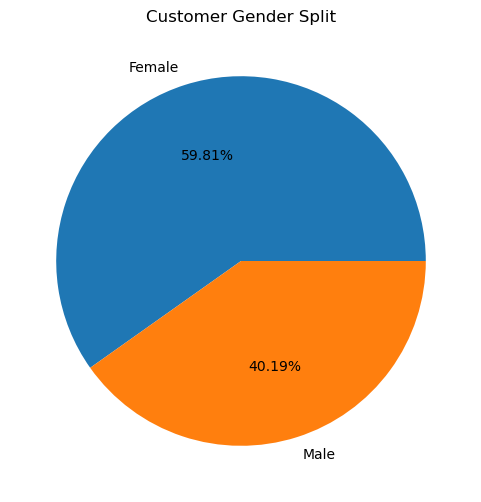

In [80]:
import matplotlib.pyplot as plt

# bar chart (category revenue)
category_sales = df.groupby("category")["total_spend"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(category_sales.index, category_sales.values)
plt.xticks()
plt.title("Total Revenue by Category")
plt.ylabel("Revenue")
plt.show()

# histogram (age distribution)
plt.figure(figsize=(10,6))
plt.hist(df["age"], bins=20, edgecolor="black")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.show()

# pie chart (gender split)
gender_counts = df["gender"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.2f%%")
plt.title("Customer Gender Split")
plt.show()